# Algoritmo Genético N-Queens (alternativa 03)

Note: you may need to restart the kernel to use updated packages.

INICIANDO EXPERIMENTOS PARA n = 8

Executando método: Substituição total (sem elitismo)
===== TABELA RESUMO =================================
Método: Substituição total (sem elitismo)
n = 8
Tempo médio de execução: 0.0556 s
Número médio de gerações até convergência: 32.00
Melhor fitness médio encontrado: 1.17
Taxa de sucesso: 6.67%
Redução média de conflitos: 83.11%


Executando método: Substituição total (com elitismo)
===== TABELA RESUMO =================================
Método: Substituição total (com elitismo)
n = 8
Tempo médio de execução: 0.1443 s
Número médio de gerações até convergência: 24.33
Melhor fitness médio encontrado: 0.67
Taxa de sucesso: 40.00%
Redução média de conflitos: 90.12%


Executando método: Manter k melhores pais
===== TABELA RESUMO =================================
Método: Manter k melhores pais
n = 8
Tempo médio de execução: 0.0994 s
Número médio de gerações até convergência: 21.00
Melhor fi

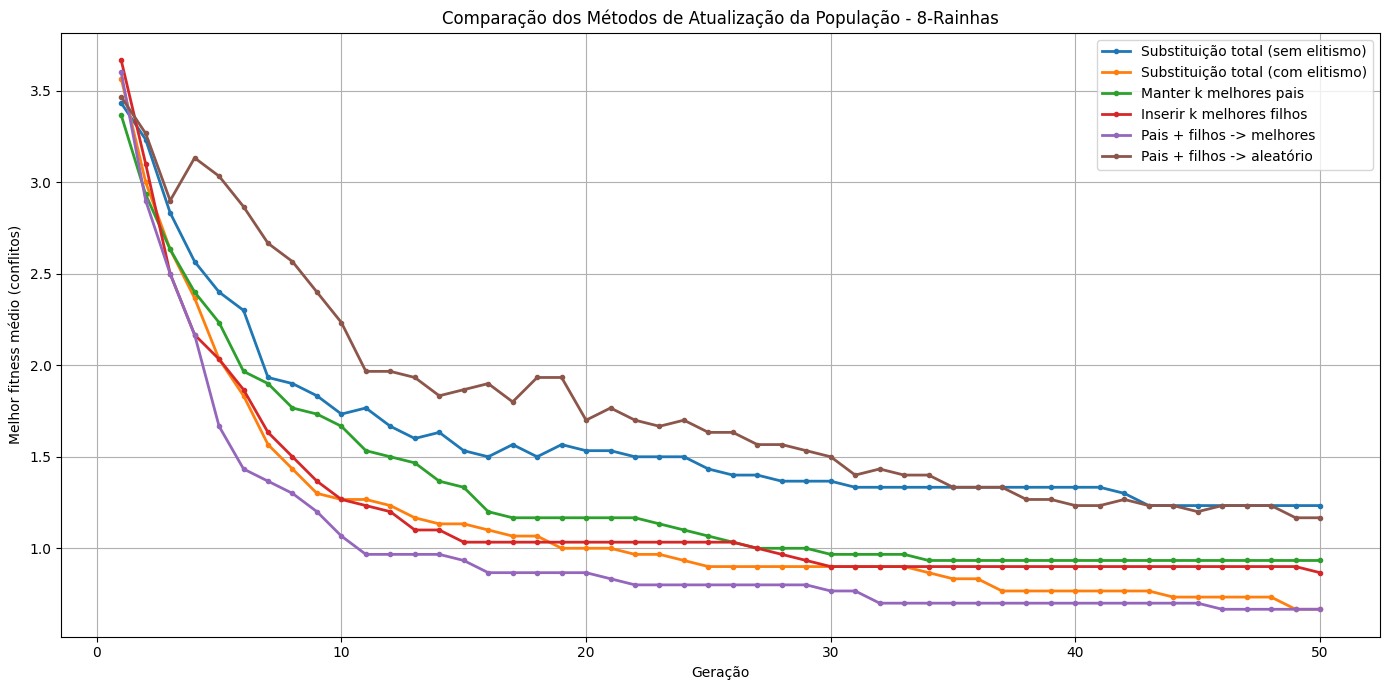


INICIANDO EXPERIMENTOS PARA n = 15

Executando método: Substituição total (sem elitismo)
===== TABELA RESUMO =================================
Método: Substituição total (sem elitismo)
n = 15
Tempo médio de execução: 0.1787 s
Número médio de gerações até convergência: não convergiu
Melhor fitness médio encontrado: 3.17
Taxa de sucesso: 0.00%
Redução média de conflitos: 78.26%


Executando método: Substituição total (com elitismo)
===== TABELA RESUMO =================================
Método: Substituição total (com elitismo)
n = 15
Tempo médio de execução: 0.5151 s
Número médio de gerações até convergência: não convergiu
Melhor fitness médio encontrado: 3.27
Taxa de sucesso: 0.00%
Redução média de conflitos: 79.05%


Executando método: Manter k melhores pais
===== TABELA RESUMO =================================
Método: Manter k melhores pais
n = 15
Tempo médio de execução: 0.3358 s
Número médio de gerações até convergência: não convergiu
Melhor fitness médio encontrado: 3.30
Taxa de su

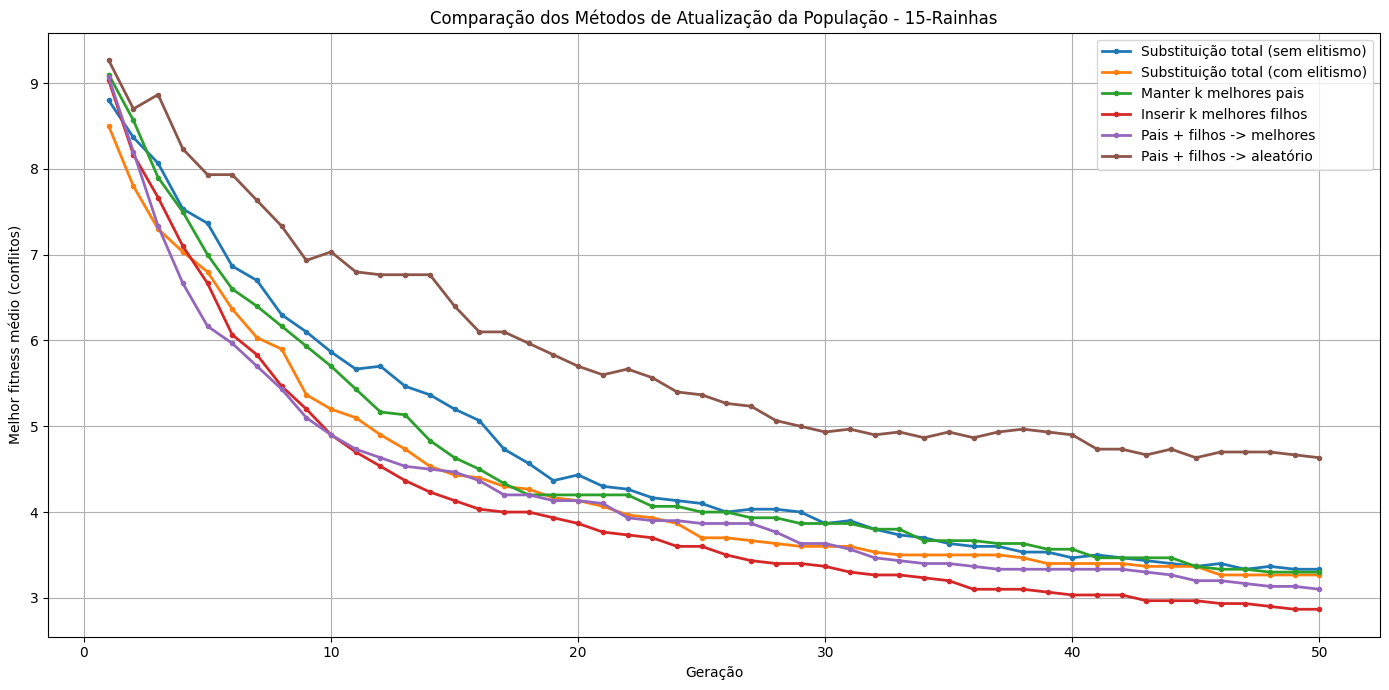


INICIANDO EXPERIMENTOS PARA n = 20

Executando método: Substituição total (sem elitismo)
===== TABELA RESUMO =================================
Método: Substituição total (sem elitismo)
n = 20
Tempo médio de execução: 0.3120 s
Número médio de gerações até convergência: não convergiu
Melhor fitness médio encontrado: 4.93
Taxa de sucesso: 0.00%
Redução média de conflitos: 75.97%


Executando método: Substituição total (com elitismo)
===== TABELA RESUMO =================================
Método: Substituição total (com elitismo)
n = 20
Tempo médio de execução: 0.8517 s
Número médio de gerações até convergência: não convergiu
Melhor fitness médio encontrado: 4.50
Taxa de sucesso: 0.00%
Redução média de conflitos: 78.63%


Executando método: Manter k melhores pais
===== TABELA RESUMO =================================
Método: Manter k melhores pais
n = 20
Tempo médio de execução: 0.5737 s
Número médio de gerações até convergência: não convergiu
Melhor fitness médio encontrado: 4.87
Taxa de su

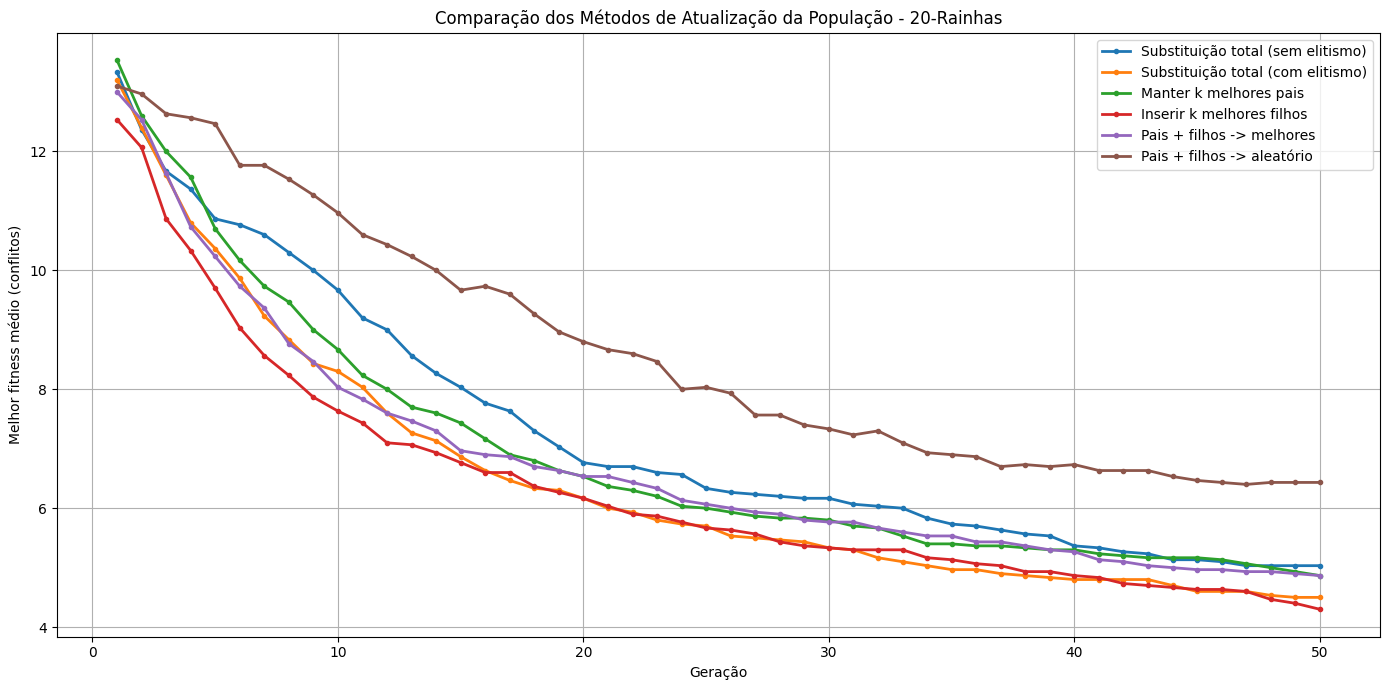


INICIANDO EXPERIMENTOS PARA n = 30

Executando método: Substituição total (sem elitismo)
===== TABELA RESUMO =================================
Método: Substituição total (sem elitismo)
n = 30
Tempo médio de execução: 0.6664 s
Número médio de gerações até convergência: não convergiu
Melhor fitness médio encontrado: 8.73
Taxa de sucesso: 0.00%
Redução média de conflitos: 72.16%


Executando método: Substituição total (com elitismo)
===== TABELA RESUMO =================================
Método: Substituição total (com elitismo)
n = 30
Tempo médio de execução: 1.8857 s
Número médio de gerações até convergência: não convergiu
Melhor fitness médio encontrado: 9.17
Taxa de sucesso: 0.00%
Redução média de conflitos: 71.88%


Executando método: Manter k melhores pais
===== TABELA RESUMO =================================
Método: Manter k melhores pais
n = 30
Tempo médio de execução: 1.2734 s
Número médio de gerações até convergência: não convergiu
Melhor fitness médio encontrado: 10.33
Taxa de s

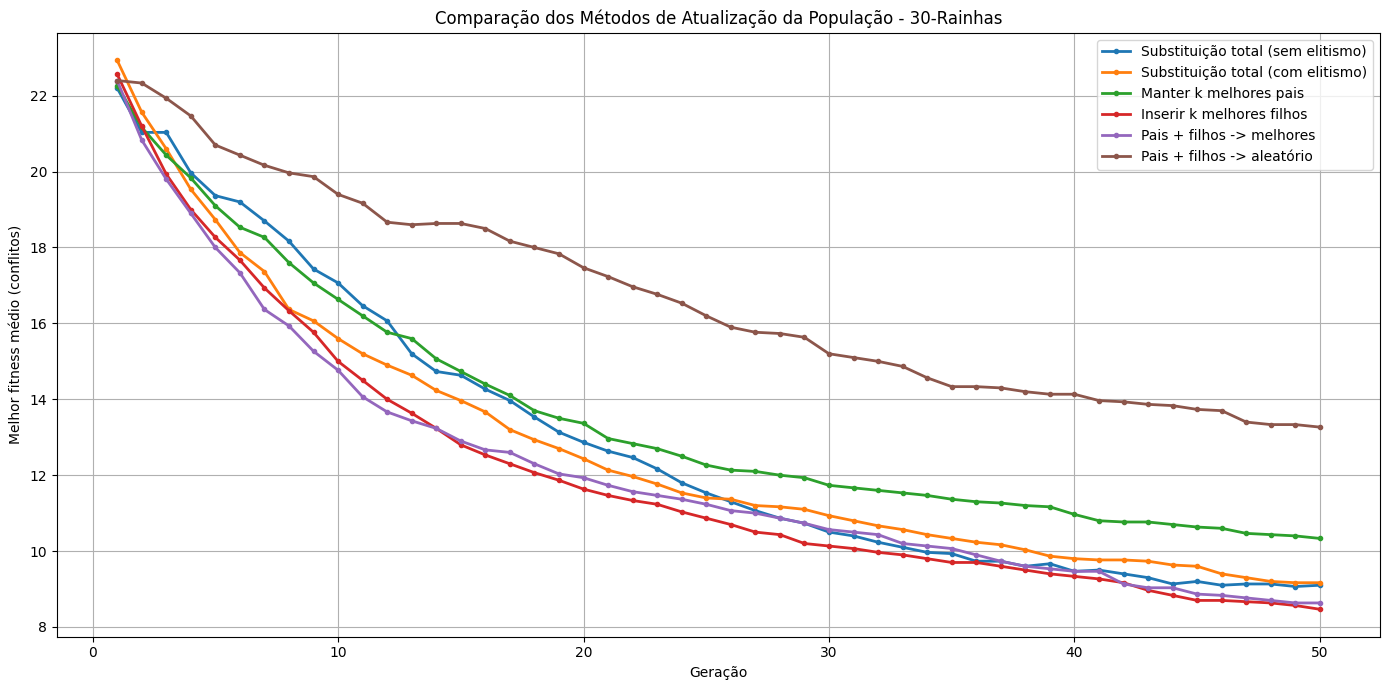


Todas as execuções concluídas.


================ TABELA COMPARATIVA FINAL ================

 Instância (n)                            Método  Tempo médio (s) Gerações médias até convergência  Taxa de sucesso (%)  Melhor fitness médio  Redução média de conflitos (%)
             8 Substituição total (sem elitismo)           0.0556                             32.0                 6.67                  1.17                           83.11
             8 Substituição total (com elitismo)           0.1443                            24.33                40.00                  0.67                           90.12
             8            Manter k melhores pais           0.0994                             21.0                20.00                  0.93                           85.77
             8         Inserir k melhores filhos           0.1450                            21.57                23.33                  0.87                           88.78
             8         Pais + filhos

In [1]:
%pip install numpy matplotlib pandas

import random
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# =========================================================
# FUNÇÕES BÁSICAS
# =========================================================

def gerar_populacao(m, n):
    matriz = np.zeros((m, n), dtype=int)
    for i in range(m):
        for j in range(n):
            matriz[i][j] = random.randint(1, n)
    return matriz

def verifica_conflitos(matriz):
    conflitos = np.zeros((matriz.shape[0], 1), dtype=int)

    for i in range(matriz.shape[0]):
        for j in range(matriz.shape[1]):
            for k in range(j + 1, matriz.shape[1]):

                # conflito na mesma linha
                if matriz[i][k] == matriz[i][j]:
                    conflitos[i] += 1

                # conflito na diagonal
                if abs(j - k) == abs(matriz[i][j] - matriz[i][k]):
                    conflitos[i] += 1

    return conflitos, conflitos.sum()

def seleciona_pai_binario(conflitos):
    pai_01_index = random.randint(0, len(conflitos) - 1)
    pai_02_index = random.randint(0, len(conflitos) - 1)

    while pai_02_index == pai_01_index:
        pai_02_index = random.randint(0, len(conflitos) - 1)

    if conflitos[pai_01_index][0] < conflitos[pai_02_index][0]:
        return pai_01_index
    else:
        return pai_02_index

def cruzamento(pai_01, pai_02, ponto_corte):
    filho_01 = np.concatenate((pai_01[:ponto_corte], pai_02[ponto_corte:]))
    filho_02 = np.concatenate((pai_02[:ponto_corte], pai_01[ponto_corte:]))
    return filho_01, filho_02

def mutacao(filho, taxa, n):
    if random.random() < taxa:
        posicao = random.randint(0, len(filho) - 1)
        novo_valor = random.randint(1, n)

        while novo_valor == filho[posicao]:
            novo_valor = random.randint(1, n)

        filho[posicao] = novo_valor

    return filho

def gerar_filhos(matriz_atual, conflitos, m, n, taxa_mutacao):
    filhos = []

    while len(filhos) < m:
        pai_01_index = seleciona_pai_binario(conflitos)
        pai_02_index = seleciona_pai_binario(conflitos)

        pai_01 = matriz_atual[pai_01_index]
        pai_02 = matriz_atual[pai_02_index]

        ponto_corte = random.randint(1, n - 1)
        filho_01, filho_02 = cruzamento(pai_01, pai_02, ponto_corte)

        filho_01 = mutacao(filho_01, taxa_mutacao, n)
        filho_02 = mutacao(filho_02, taxa_mutacao, n)

        filhos.append(filho_01)
        if len(filhos) < m:
            filhos.append(filho_02)

    return np.array(filhos)

# =========================================================
# MÉTODOS DE ATUALIZAÇÃO
# =========================================================

# funções criadas com auxílio de IA
def atualizacao_sem_elitismo(filhos):
    return filhos.copy()

def atualizacao_com_elitismo(matriz_atual, filhos):
    conflitos_pais, _ = verifica_conflitos(matriz_atual)
    conflitos_filhos, _ = verifica_conflitos(filhos)

    melhor_pai_idx = np.argmin(conflitos_pais)
    pior_filho_idx = np.argmax(conflitos_filhos)

    nova_populacao = filhos.copy()
    nova_populacao[pior_filho_idx] = matriz_atual[melhor_pai_idx].copy()

    return nova_populacao

def atualizacao_k_melhores_pais(matriz_atual, filhos, m, k):
    conflitos_pais, _ = verifica_conflitos(matriz_atual)

    indices_ordenados_pais = np.argsort(conflitos_pais.flatten())
    melhores_pais = matriz_atual[indices_ordenados_pais[:k]]

    quantidade_filhos_necessaria = m - k
    filhos_utilizados = filhos[:quantidade_filhos_necessaria]

    nova_populacao = np.vstack((melhores_pais, filhos_utilizados))
    return nova_populacao

def atualizacao_k_melhores_filhos(matriz_atual, filhos, m, k):
    conflitos_filhos, _ = verifica_conflitos(filhos)
    conflitos_pais, _ = verifica_conflitos(matriz_atual)

    indices_ordenados_filhos = np.argsort(conflitos_filhos.flatten())
    melhores_filhos = filhos[indices_ordenados_filhos[:k]]

    quantidade_pais_necessaria = m - k
    indices_ordenados_pais = np.argsort(conflitos_pais.flatten())
    melhores_pais = matriz_atual[indices_ordenados_pais[:quantidade_pais_necessaria]]

    nova_populacao = np.vstack((melhores_pais, melhores_filhos))
    return nova_populacao

def atualizacao_pais_filhos_melhores(matriz_atual, filhos, m):
    populacao_combinada = np.vstack((matriz_atual, filhos))
    conflitos_combinados, _ = verifica_conflitos(populacao_combinada)

    indices_ordenados = np.argsort(conflitos_combinados.flatten())
    melhores_indices = indices_ordenados[:m]

    nova_populacao = populacao_combinada[melhores_indices]
    return nova_populacao

def atualizacao_pais_filhos_aleatoria(matriz_atual, filhos, m):
    populacao_combinada = np.vstack((matriz_atual, filhos))
    indices_escolhidos = np.random.choice(populacao_combinada.shape[0], size=m, replace=False)

    nova_populacao = populacao_combinada[indices_escolhidos]
    return nova_populacao

# =========================================================
# EXECUÇÃO DO AG - ALTERNATIVA 03
# =========================================================

# função aprimorada por IA, com base no código da versão básica
def executar_alternativa3(m, n, geracoes, taxa_mutacao, metodo, k):
    inicio = time.time()

    matriz_inicial = gerar_populacao(m, n)
    conflitos_iniciais, qtdd_conflitos_inicial = verifica_conflitos(matriz_inicial)

    matriz_atual = matriz_inicial.copy()

    historico_media = []
    historico_melhor = []

    melhor_conflito_global = 999999
    melhor_individuo_global = None
    melhor_geracao_global = -1

    # começa como -1 (não convergiu)
    geracao_convergencia = -1

    for geracao in range(geracoes):
        conflitos, conflitos_total = verifica_conflitos(matriz_atual)
        media_conflitos = conflitos_total / m
        melhor_conflito_geracao = int(conflitos.min())
        melhor_indice_geracao = int(np.argmin(conflitos))

        historico_media.append(media_conflitos)
        historico_melhor.append(melhor_conflito_geracao)

        if melhor_conflito_geracao < melhor_conflito_global:
            melhor_conflito_global = melhor_conflito_geracao
            melhor_individuo_global = matriz_atual[melhor_indice_geracao].copy()
            melhor_geracao_global = geracao + 1

        # registra a primeira geração com solução perfeita
        if geracao_convergencia == -1 and melhor_conflito_geracao == 0:
            geracao_convergencia = geracao + 1

        filhos = gerar_filhos(matriz_atual, conflitos, m, n, taxa_mutacao)

        if metodo == "sem_elitismo":
            matriz_atual = atualizacao_sem_elitismo(filhos)

        elif metodo == "com_elitismo":
            matriz_atual = atualizacao_com_elitismo(matriz_atual, filhos)

        elif metodo == "k_melhores_pais":
            matriz_atual = atualizacao_k_melhores_pais(matriz_atual, filhos, m, k)

        elif metodo == "k_melhores_filhos":
            matriz_atual = atualizacao_k_melhores_filhos(matriz_atual, filhos, m, k)

        elif metodo == "pais_filhos_melhores":
            matriz_atual = atualizacao_pais_filhos_melhores(matriz_atual, filhos, m)

        elif metodo == "pais_filhos_aleatoria":
            matriz_atual = atualizacao_pais_filhos_aleatoria(matriz_atual, filhos, m)

        else:
            raise ValueError("Método inválido.")

    conflitos_finais, qtdd_conflitos_final = verifica_conflitos(matriz_atual)
    tempo_execucao = time.time() - inicio

    # percentual de redução de conflitos
    if qtdd_conflitos_inicial > 0:
        reducao_percentual = ((qtdd_conflitos_inicial - qtdd_conflitos_final) / qtdd_conflitos_inicial) * 100
    else:
        reducao_percentual = 0

    return {
        "qtdd_conflitos_inicial": int(qtdd_conflitos_inicial),
        "qtdd_conflitos_final": int(qtdd_conflitos_final),
        "historico_media": historico_media,
        "historico_melhor": historico_melhor,
        "melhor_conflito_global": int(melhor_conflito_global),
        "melhor_individuo_global": melhor_individuo_global,
        "melhor_geracao_global": melhor_geracao_global,
        "geracao_convergencia": geracao_convergencia,
        "tempo_execucao": tempo_execucao,
        "reducao_percentual": reducao_percentual
    }

# =========================================================
# CONFIGURAÇÕES GERAIS
# =========================================================

# abstração feita por IA, após testes realizados isoladamente
num_execucoes = 30
instancias_n = [8, 15, 20, 30]
m = 50
geracoes = 50
taxa_mutacao = 0.05
k = 15

metodos = [
    "sem_elitismo",
    "com_elitismo",
    "k_melhores_pais",
    "k_melhores_filhos",
    "pais_filhos_melhores",
    "pais_filhos_aleatoria"
]

nomes_metodos = {
    "sem_elitismo": "Substituição total (sem elitismo)",
    "com_elitismo": "Substituição total (com elitismo)",
    "k_melhores_pais": "Manter k melhores pais",
    "k_melhores_filhos": "Inserir k melhores filhos",
    "pais_filhos_melhores": "Pais + filhos -> melhores",
    "pais_filhos_aleatoria": "Pais + filhos -> aleatório"
}

# =========================================================
# EXPERIMENTOS
# =========================================================

tabela_comparativa = []

# laço criado por IA para organizar a execução dos experimentos e a coleta dos resultados
for n in instancias_n:
    print("\n" + "=" * 90)
    print(f"INICIANDO EXPERIMENTOS PARA n = {n}")
    print("=" * 90)

    resultados_por_metodo = {}

    for metodo_escolhido in metodos:
        print(f"\nExecutando método: {nomes_metodos[metodo_escolhido]}")
        resultados_execucoes = []

        for execucao in range(num_execucoes):
            resultado = executar_alternativa3(
                m=m,
                n=n,
                geracoes=geracoes,
                taxa_mutacao=taxa_mutacao,
                metodo=metodo_escolhido,
                k=k
            )
            resultados_execucoes.append(resultado)

        tempos = [r["tempo_execucao"] for r in resultados_execucoes]
        melhores_finais = [r["melhor_conflito_global"] for r in resultados_execucoes]
        sucessos = [1 if r["melhor_conflito_global"] == 0 else 0 for r in resultados_execucoes]
        reducoes = [r["reducao_percentual"] for r in resultados_execucoes]

        # só conta execuções que realmente convergiram
        geracoes_validas = [r["geracao_convergencia"] for r in resultados_execucoes if r["geracao_convergencia"] != -1]

        tempo_medio = np.mean(tempos)
        melhor_fitness_medio = np.mean(melhores_finais)
        taxa_sucesso = np.mean(sucessos) * 100
        reducao_media = np.mean(reducoes)

        if len(geracoes_validas) > 0:
            geracoes_medias = np.mean(geracoes_validas)
        else:
            geracoes_medias = -1

        print("===== TABELA RESUMO =================================")
        print(f"Método: {nomes_metodos[metodo_escolhido]}")
        print(f"n = {n}")
        print(f"Tempo médio de execução: {tempo_medio:.4f} s")
        if geracoes_medias == -1:
            print("Número médio de gerações até convergência: não convergiu")
        else:
            print(f"Número médio de gerações até convergência: {geracoes_medias:.2f}")
        print(f"Melhor fitness médio encontrado: {melhor_fitness_medio:.2f}")
        print(f"Taxa de sucesso: {taxa_sucesso:.2f}%")
        print(f"Redução média de conflitos: {reducao_media:.2f}%")
        print("=====================================================\n")

        historicos_media = np.array([r["historico_media"] for r in resultados_execucoes])
        historicos_melhor = np.array([r["historico_melhor"] for r in resultados_execucoes])

        media_historico_media = np.mean(historicos_media, axis=0)
        media_historico_melhor = np.mean(historicos_melhor, axis=0)

        resultados_por_metodo[metodo_escolhido] = {
            "tempo_medio": tempo_medio,
            "geracoes_medias": geracoes_medias,
            "melhor_fitness_medio": melhor_fitness_medio,
            "taxa_sucesso": taxa_sucesso,
            "reducao_media": reducao_media,
            "media_historico_media": media_historico_media,
            "media_historico_melhor": media_historico_melhor
        }

        tabela_comparativa.append({
            "Instância (n)": n,
            "Método": nomes_metodos[metodo_escolhido],
            "Tempo médio (s)": tempo_medio,
            "Gerações médias até convergência": geracoes_medias,
            "Taxa de sucesso (%)": taxa_sucesso,
            "Melhor fitness médio": melhor_fitness_medio,
            "Redução média de conflitos (%)": reducao_media
        })

    # ---------- GRÁFICO PARA CADA n ----------

    plt.figure(figsize=(14, 7))

    for metodo in metodos:
        plt.plot(
            range(1, geracoes + 1),
            resultados_por_metodo[metodo]["media_historico_melhor"],
            marker='o',
            markersize=3,
            linewidth=2,
            label=nomes_metodos[metodo]
        )

    plt.xlabel("Geração")
    plt.ylabel("Melhor fitness médio (conflitos)")
    plt.title(f"Comparação dos Métodos de Atualização da População - {n}-Rainhas")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

print("\nTodas as execuções concluídas.")

# =========================================================
# TABELA COMPARATIVA FINAL
# =========================================================

# estrutura da tabela gerada por IA

df_tabela = pd.DataFrame(tabela_comparativa)

# formatação
df_tabela["Tempo médio (s)"] = df_tabela["Tempo médio (s)"].round(4)
df_tabela["Gerações médias até convergência"] = df_tabela["Gerações médias até convergência"].apply(
    lambda x: "Não convergiu" if x == -1 else round(x, 2)
)
df_tabela["Taxa de sucesso (%)"] = df_tabela["Taxa de sucesso (%)"].round(2)
df_tabela["Melhor fitness médio"] = df_tabela["Melhor fitness médio"].round(2)
df_tabela["Redução média de conflitos (%)"] = df_tabela["Redução média de conflitos (%)"].round(2)

print("\n\n================ TABELA COMPARATIVA FINAL ================\n")
print(df_tabela.to_string(index=False))